In [1]:
%pip install einops numpy pillow -q


In [7]:
import numpy as np
from IPython import get_ipython
from IPython.display import display_html
from PIL.Image import fromarray
import requests
from io import BytesIO

In [8]:
def display_np_arrays_as_images():
    def np_to_png(a):
        if 2 <= len(a.shape) <= 3:
            return fromarray(np.array(np.clip(a, 0, 1) * 255, dtype="uint8"))._repr_png_()
        else:
            return fromarray(np.zeros([1, 1], dtype="uint8"))._repr_png_()

    def np_to_text(obj, p, cycle):
        if len(obj.shape) < 2:
            print(repr(obj))
        if 2 <= len(obj.shape) <= 3:
            pass
        else:
            print(f"<array of shape {obj.shape}>")

    get_ipython().display_formatter.formatters["image/png"].for_type(np.ndarray, np_to_png)
    get_ipython().display_formatter.formatters["text/plain"].for_type(np.ndarray, np_to_text)


_style_inline = """<style>
.einops-answer {
    color: transparent;
    padding: 5px 15px;
    background-color: #def;
}
.einops-answer:hover { color: blue; }
</style>
"""


def guess(x):
    display_html(
        _style_inline + f"<h4>Answer is: <span class='einops-answer'>{tuple(x)}</span> (hover to see)</h4>",
        raw=True,
    )

In [9]:
# Examples are given for numpy. This code also setups ipython/jupyter/jupyterlite
# so that numpy arrays in the output are displayed as images

display_np_arrays_as_images()

In [10]:
url = "https://github.com/arogozhnikov/einops/raw/refs/heads/main/docs/resources/test_images.npy"

response = requests.get(url)
response.raise_for_status()

arr = np.load(BytesIO(response.content))

print(arr.shape)

(6, 96, 96, 3)


In [16]:
print(arr[0])

[[[1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  ...
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]]

 [[1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  ...
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]]

 [[1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  ...
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]]

 ...

 [[1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  ...
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]]

 [[1.         0.90196078 0.90196078]
  [1.         0.90196078 0.90196078]


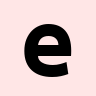

In [17]:
arr[0]

In [15]:
from einops import rearrange, reduce, repeat


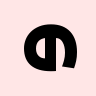

In [ ]:
rearrange(arr[0], 'h w c -> w h c')

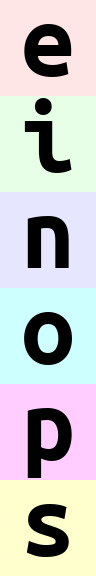

In [19]:
rearrange(arr, 'b h w c -> (b h) w c')

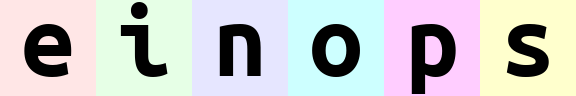

In [20]:
rearrange(arr, 'b h w c -> h (b w) c')

In [23]:
rearrange(arr, '(b1 b2) h w c -> b1 b2 h w c', b1=2).shape

(2, 3, 96, 96, 3)

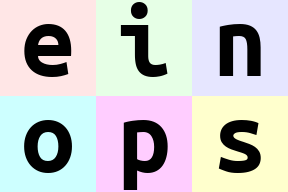

In [24]:
rearrange(arr, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=2)

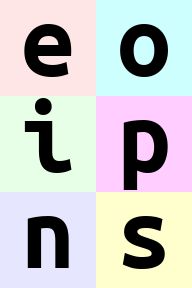

In [26]:
rearrange(arr, "(b1 b2) h w c -> (b2 h) (b1 w) c ", b1=2)

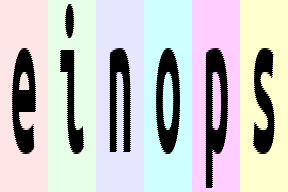

In [27]:
rearrange(arr, 'b h (w w1) c -> (h w1) (b w) c', w1=2)

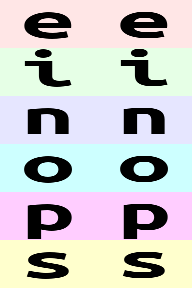

In [28]:
rearrange(arr, '(h w1) (b w) c -> b h (w w1) c', h1=2)